# 🚀 Practice Day 11

**📅 Date:** 2026-09-22  
**📁 Category:** Phase 3 · SQL 고급 윈도우 함수 (Round 1/5)

---
# 🎯 Today's Goal
*What am I trying to solve today?*

- Rank rows within a result set using RANK() OVER (RANK() OVER로 결과 내 순위 매기기)
- Compute a running total with SUM() OVER (SUM() OVER로 누적합 계산)
- Smooth out daily noise with a moving average using AVG() OVER with a frame (AVG() OVER의 프레임으로 이동평균 계산해 일별 노이즈 완화)

---
# 📂 Dataset

**Dataset Name:** Website Daily Traffic (웹사이트 일별 트래픽 데이터)

**Source:** Synthetically generated for practice, fixed random seed (연습용으로 코드에서 직접 생성, seed 고정)

**Description:** 180 days of website traffic (2026-01-24 to 2026-07-22): visitors, page views, and signups. Weekdays run higher than weekends, there's a mild upward growth trend over the period, and 3 days are deliberately injected as traffic spikes ("viral" days) so RANK() has something real to surface.
(웹사이트 트래픽 180일치(2026-01-24~2026-07-22) — 방문자수, 페이지뷰, 가입자수 포함. 평일이 주말보다 높고, 기간 전체에 걸쳐 완만한 성장 추세가 있으며, RANK()가 실제로 잡아낼 수 있도록 트래픽 급증일("바이럴" 3일)을 의도적으로 포함했습니다.)

## Dataset Preview

In [41]:
# Dataset Preview
import pandas as pd
import numpy as np

np.random.seed(42)

n_days = 180
dates = pd.date_range('2026-01-24', periods=n_days, freq='D')
day_names = dates.day_name()
weekend_mask = day_names.isin(['Saturday', 'Sunday'])

base_visitors = 1200
growth = 1 + 0.0025 * np.arange(n_days)  # mild upward trend over the 180 days
weekday_factor = np.where(weekend_mask, 0.75, 1.05)

visitors = np.round(base_visitors * growth * weekday_factor * np.random.normal(1.0, 0.08, n_days)).astype(int)

# inject 3 deliberate traffic-spike ("viral") days
spike_days = np.random.choice(n_days, size=3, replace=False)
visitors[spike_days] = (visitors[spike_days] * np.random.uniform(2.2, 3.2, size=3)).astype(int)

page_views = np.round(visitors * np.random.normal(3.2, 0.3, n_days)).astype(int)
signups = np.round(visitors * np.random.uniform(0.02, 0.05, n_days)).astype(int)

df = pd.DataFrame({
    'date': dates,
    'visitors': visitors,
    'page_views': page_views,
    'signups': signups,
})

df.head()

,date,visitors,page_views,signups
0,2026-01-24,936,2562,46
1,2026-01-25,892,3153,34
2,2026-01-26,1332,3801,36
3,2026-01-27,1424,5228,64
4,2026-01-28,1249,3575,38


## Dataset Information

In [42]:
# Dataset Information
import duckdb

print(df.shape)
df.info()
df.describe()

(180, 4)
<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        180 non-null    datetime64[us]
 1   visitors    180 non-null    int64         
 2   page_views  180 non-null    int64         
 3   signups     180 non-null    int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 5.8 KB


,date,visitors,page_views,signups
count,180,180.000000,180.000000,180.000000
mean,2026-04-23 12:00:00,1447.277778,4613.894444,50.916667
min,2026-01-24 00:00:00,803.000000,2259.000000,18.000000
25%,2026-03-09 18:00:00,1220.250000,3782.500000,38.000000
50%,2026-04-23 12:00:00,1440.500000,4444.500000,50.000000
75%,2026-06-07 06:00:00,1609.250000,5232.250000,62.000000
max,2026-07-22 00:00:00,3783.000000,11717.000000,121.000000
std,NaN,385.428167,1312.535346,16.553916


---
# ❓ Business Questions

1. What are the top 10 days by visitor count? (방문자 수 기준 상위 10일은?)
2. What is the cumulative (running total) visitor count over time? (시간에 따른 누적 방문자 수는?)
3. What is the 7-day moving average of visitors? (방문자 수의 7일 이동평균은?)
4. How does the daily visitor count compare to its 7-day moving average? (일별 방문자 수와 7일 이동평균을 비교하면 어떤 모습인가?)
5. What is the average visitor count for each day of the week? (요일별 평균 방문자 수는?)

---
# 🛠 Skills Used
- [x] Python
- [ ] NumPy
- [x] Pandas — `.df()`
  (SQL 결과를 DataFrame으로)
- [x] SQL — `RANK() OVER`, `QUALIFY`, `SUM() OVER`, `AVG() OVER`, `ROWS BETWEEN`, `EXTRACT(ISODOW)`
  (순위, QUALIFY, 누적합, 이동평균, 윈도우 프레임, 요일 번호)
- [x] Matplotlib
- [ ] Other: 

---
# 🔍 Data Cleaning Check

Things I checked:
- [x] Missing Values — 0
  (결측 없음)
- [x] Duplicate Rows — 0
  (중복 행 없음)
- [x] Wrong Data Types — date is datetime; visitors/page_views/signups are int; no text columns
  (날짜는 datetime, 나머지는 정수. 텍스트 컬럼 없음)
- [ ] Rename Columns — not needed
  (불필요)
- [ ] Drop Columns — not needed
  (불필요)


In [43]:
# Data Cleaning Check — inspect only. Fixes are in Q1–Q3.
# (확인만. 수정은 Q1~Q3)

print("Missing values")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDtypes")
print(df.dtypes)

print("\nColumn names")
print(df.columns.tolist())

obj_cols = df.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(df[obj_cols].nunique())


Missing values
date          0
visitors      0
page_views    0
signups       0
dtype: int64

Duplicate rows: 0

Dtypes
date          datetime64[us]
visitors               int64
page_views             int64
signups                int64
dtype: object

Column names
['date', 'visitors', 'page_views', 'signups']

Text columns — unique counts
Series([], dtype: float64)


---
# 📊 Analysis

## Question 1

**Question:** What are the top 10 days by visitor count? (방문자 수 기준 상위 10일은?)

**Result:** Top 3 days: **3,783** (2026-03-05, Thu), **3,324** (2026-04-29, Wed), **3,224** (2026-01-30, Fri). Ranks 4 to 10 are **1,900** to **2,221**.
(상위 3일은 3,783(목), 3,324(수), 3,224(금). 4~10위는 1,900~2,221)

**Insight:** The top 3 are far above the rest and fall on Wed, Thu, and Fri. All 10 days are weekdays.
(상위 3일은 나머지보다 훨씬 높고 수·목·금. 10일 모두 평일)

In [53]:
# Question 1: RANK() OVER (ORDER BY visitors DESC), then keep the top 10
# Tip: filter with QUALIFY (DuckDB/BigQuery) or wrap in a subquery + WHERE rank <= 10
# (duckdb.sql()로 SQL 쿼리 작성)

duckdb.sql("""
    SELECT date, visitors, 
           dayname(date) AS day_of_week,
           RANK() OVER (ORDER BY visitors DESC) AS rank
    FROM df 
    QUALIFY rank <= 10
    ORDER BY rank
""").df()

,date,visitors,day_of_week,rank
0,2026-03-05,3783,Thursday,1
1,2026-04-29,3324,Wednesday,2
2,2026-01-30,3224,Friday,3
3,2026-07-22,2221,Wednesday,4
4,2026-07-10,2057,Friday,5
5,2026-07-20,2029,Monday,6
6,2026-06-29,2013,Monday,7
7,2026-05-29,1944,Friday,8
8,2026-07-07,1914,Tuesday,9
9,2026-07-09,1900,Thursday,10


In [45]:
duckdb.sql("""
    SELECT date, visitors, dayname(date) AS day_of_week
    FROM df
    WHERE visitors >= (SELECT AVG(visitors) FROM df)
    ORDER BY visitors DESC
""").df()

,date,visitors,day_of_week
0,2026-03-05,3783,Thursday
1,2026-04-29,3324,Wednesday
2,2026-01-30,3224,Friday
3,2026-07-22,2221,Wednesday
4,2026-07-10,2057,Friday
...,...,...,...
85,2026-06-03,1462,Wednesday
86,2026-03-31,1459,Tuesday
87,2026-04-17,1458,Friday
88,2026-02-27,1457,Friday


In [46]:
duckdb.sql("""
    SELECT dayname(date) AS day_of_week, COUNT(*) AS count
    FROM df
    WHERE visitors >= (SELECT AVG(visitors) FROM df)
    GROUP BY dayname(date)
    ORDER BY count DESC
""").df()

,day_of_week,count
0,Friday,20
1,Tuesday,19
2,Thursday,18
3,Wednesday,17
4,Monday,16


## Question 2

**Question:** What is the cumulative (running total) visitor count over time? (시간에 따른 누적 방문자 수는?)

**Result:** The running total starts at **936** (2026-01-24) and reaches **260,510** on 2026-07-22.
(누적 방문자 수는 936에서 시작해 260,510까지)

**Insight:** The running total only goes up, so it cannot show daily ups and downs. Use Q3 for the trend.
(누적합은 올라가기만 해서 일별 등락은 안 보임. 추세는 Q3로 볼 것)

In [47]:
# Question 2: SUM(visitors) OVER (ORDER BY date) as a running total
# (duckdb.sql()로 SQL 쿼리 작성)

duckdb.sql("""
    SELECT date, visitors,
           SUM(visitors) OVER (ORDER BY date) AS cumulative_visitors
    FROM df
    ORDER BY date
""").df()

,date,visitors,cumulative_visitors
0,2026-01-24,936,936.0
1,2026-01-25,892,1828.0
2,2026-01-26,1332,3160.0
3,2026-01-27,1424,4584.0
4,2026-01-28,1249,5833.0
...,...,...,...
175,2026-07-18,1379,253181.0
176,2026-07-19,1297,254478.0
177,2026-07-20,2029,256507.0
178,2026-07-21,1782,258289.0


## Question 3

**Question:** What is the 7-day moving average of visitors? (방문자 수의 7일 이동평균은?)

**Result:** The 7-day moving average goes from **1,197** (2026-02-23) to **1,773** (2026-07-22). The first 6 days use a shorter window.
(7일 이동평균은 1,197에서 1,773으로 상승. 처음 6일은 짧은 구간 평균)

**Insight:** The trend is upward overall, not a straight line. It dips and rises along the way.
(전체적으로 우상향이지만 직선은 아님. 중간에 오르내림이 있음)

In [48]:
# Question 3: AVG(visitors) OVER (ORDER BY date ROWS BETWEEN 6 PRECEDING AND CURRENT ROW)
# (duckdb.sql()로 SQL 쿼리 작성, 7일 윈도우 프레임 사용)

duckdb.sql("""
    SELECT date, visitors,
           AVG(visitors) OVER (
               ORDER BY date
               ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
           ) AS ma7
    FROM df
    ORDER BY date
""").df()


,date,visitors,ma7
0,2026-01-24,936,936.000000
1,2026-01-25,892,914.000000
2,2026-01-26,1332,1053.333333
3,2026-01-27,1424,1146.000000
4,2026-01-28,1249,1166.600000
...,...,...,...
175,2026-07-18,1379,1632.000000
176,2026-07-19,1297,1645.428571
177,2026-07-20,2029,1697.000000
178,2026-07-21,1782,1711.428571


---
# 📈 Visualization

**Chart 1:** Daily visitors vs. 7-day moving average (line chart) — 일별 방문자 수 vs 7일 이동평균

**Interpretation:** The 7-day average rises from about **1,200** to about **1,770**. Three daily spikes stand far above it (**3,224**, **3,783**, **3,324**).
(7일 평균은 약 1,200에서 약 1,770으로 상승. 3,224, 3,783, 3,324의 세 날이 크게 튐)

---

**Chart 2:** Average visitors by day of week (bar chart) — 요일별 평균 방문자 수

**Interpretation:** Weekends are low (Sat **1,083**, Sun **1,116**) and weekdays are high (Mon **1,518** to Thu **1,645**). Wed, Thu, and Fri are the highest bars, and the three spike days also fall on Wed, Thu, and Fri.
(주말은 낮고 평일은 높음. 수·목·금이 가장 높고, 튄 3일도 수·목·금)

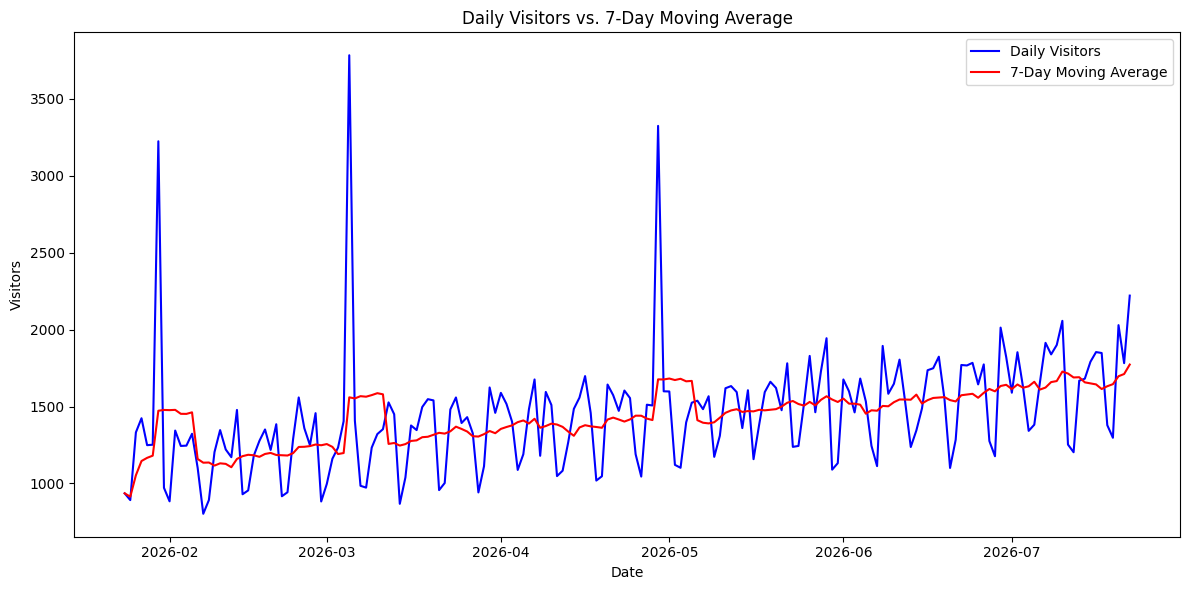

,day_of_week,avg_visitors
0,1,1517.692308
1,2,1559.346154
2,3,1596.038462
3,4,1644.960000
4,5,1628.360000
5,6,1082.730769
6,7,1116.384615


,day_of_week,avg_visitors
0,1,1517.692308
1,2,1559.346154
2,3,1526.920000
3,4,1555.875000
4,5,1561.875000
5,6,1082.730769
6,7,1116.384615


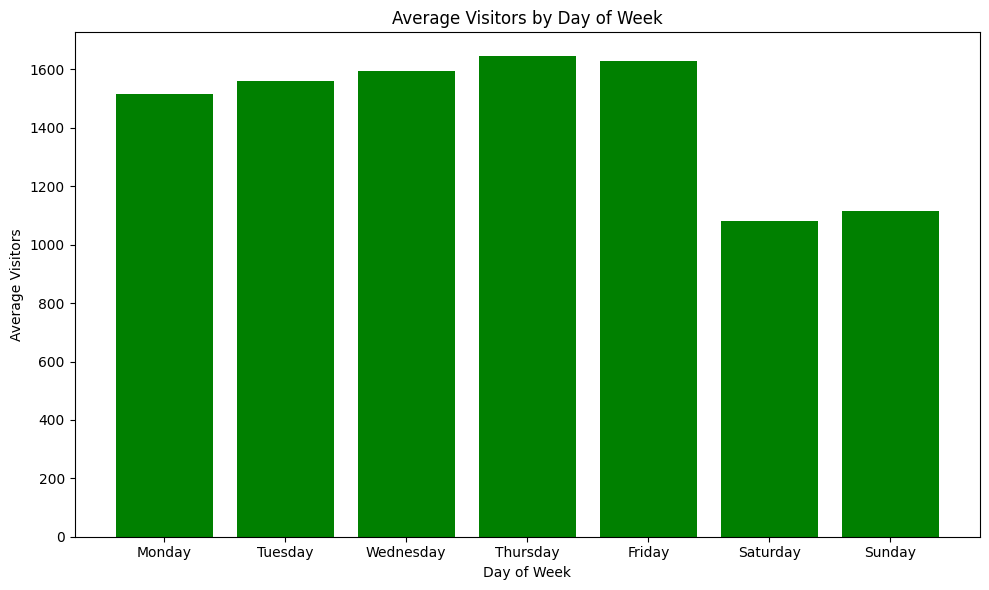

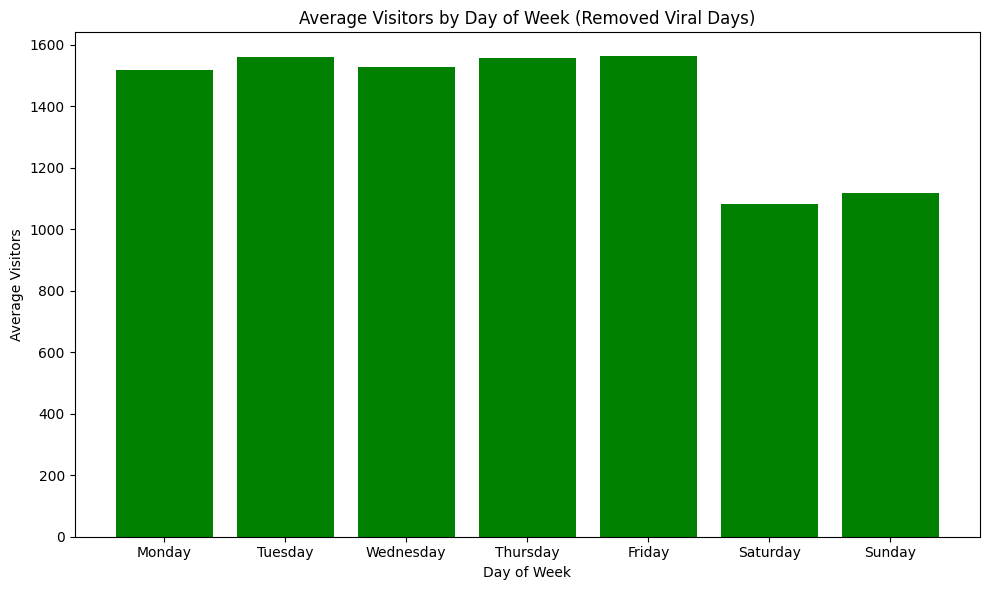

In [57]:
# Visualization
import matplotlib.pyplot as plt
# import seaborn as sns

# Chart 1: Daily visitors (noisy line) vs. its 7-day moving average (smooth line), same axes
data1 = duckdb.sql("""
    SELECT date, visitors,
           AVG(visitors) OVER (
               ORDER BY date
               ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
           ) AS ma7
    FROM df
    ORDER BY date
""").df()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(data1['date'], data1['visitors'], label='Daily Visitors', color='blue')
ax.plot(data1['date'], data1['ma7'], label='7-Day Moving Average', color='red')
ax.set_xlabel('Date')
ax.set_ylabel('Visitors')
ax.set_title('Daily Visitors vs. 7-Day Moving Average')
ax.legend()
plt.tight_layout()
plt.show()

# Chart 2: Average visitors by day of week (bar chart)
data2 = duckdb.sql("""
    SELECT EXTRACT(ISODOW FROM date) AS day_of_week,
       AVG(visitors) AS avg_visitors
    FROM df
    GROUP BY EXTRACT(ISODOW FROM date)
    ORDER BY day_of_week
""").df()
display(data2)

data2_remove_viral = duckdb.sql("""
    SELECT EXTRACT(ISODOW FROM date) AS day_of_week,
       AVG(visitors) AS avg_visitors
    FROM (
        SELECT date, visitors,
               RANK() OVER (ORDER BY visitors DESC) AS rank
        FROM df
    )
    WHERE rank > 3
    GROUP BY EXTRACT(ISODOW FROM date)
    ORDER BY day_of_week
""").df()
display(data2_remove_viral)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(data2['day_of_week'], data2['avg_visitors'], color='green')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Visitors')
ax.set_title('Average Visitors by Day of Week')
ax.set_xticks(data2['day_of_week'])
ax.set_xticklabels(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(data2_remove_viral['day_of_week'], data2_remove_viral['avg_visitors'], color='green')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Visitors')
ax.set_title('Average Visitors by Day of Week (Removed Viral Days)')
ax.set_xticks(data2_remove_viral['day_of_week'])
ax.set_xticklabels(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.tight_layout()
plt.show()


---
# 💼 Business Insights
**What did I discover?**

- The top 3 days (**3,783**, **3,324**, **3,224**) are far above rank 4 (**2,221**). All top 10 days are weekdays.
  (상위 3일은 4위 2,221보다 훨씬 높음. 상위 10일은 모두 평일)
- The 7-day average rises from **1,197** to **1,773**. The running total only goes up (**260,510** at the end), so it hides daily ups and downs.
  (7일 평균은 1,197에서 1,773으로 상승. 누적합은 올라가기만 해서 등락이 안 보임)
- Weekends are low (Sat **1,083**, Sun **1,116**) vs weekdays (**1,518** to **1,645**). The three spike days also fall on Wed, Thu, and Fri.
  (주말은 낮고 평일은 높음. 튄 3일도 수·목·금)
 

---
# 🎯 Business Recommendation
**If I were the Business Analyst...**

1. Do not plan from the spike days. Use the 7-day average (about **1,770**) as the baseline, not **3,783**.
   (바이럴 날을 기준으로 계획하지 말 것. 3,783이 아니라 7일 평균 약 1,770을 기준으로)
2. Do not call Wed, Thu, and Fri the best weekdays. The three spike days are on those days.
   (수·목·금을 가장 좋은 평일로 단정하지 말 것. 튄 3일이 그 요일에 있음)
3. Plan weekends separately (Sat **1,083**, Sun **1,116**). Do not judge growth by the running total; use the 7-day average.
   (주말은 따로 계획. 성장은 누적합이 아니라 7일 평균으로 볼 것)
 

---
# ❌ Mistakes
**What mistakes did I make today?**

- `PARTITION BY visitors` made every rank 1, and `WHERE rank <= 10` is not allowed. Use `ORDER BY visitors DESC` and `QUALIFY`.
  (PARTITION BY visitors는 순위가 전부 1. WHERE에서는 rank를 쓸 수 없음. ORDER BY DESC와 QUALIFY)
- `DAYOFWEEK` starts at Sunday = 0, so the labels were shifted and `+ 1` did not fix it. `ISODOW` starts at Monday = 1.
  (DAYOFWEEK는 일요일이 0이라 라벨이 어긋남. +1로 안 고쳐짐. ISODOW는 월요일이 1)
- `WHERE` must come before `GROUP BY`, and `SELECT` cannot list `date` or `visitors` after grouping by weekday.
  (WHERE는 GROUP BY 앞. 요일로 묶으면 date, visitors는 SELECT에 못 씀)
 

---
# ✅ What I Learned
**Today's biggest lesson**

- `RANK() OVER (ORDER BY ... DESC)` ranks all rows. `QUALIFY` filters on a window result in one query; a subquery with `WHERE` does the same.
  (RANK로 전체 순위. QUALIFY는 윈도우 결과를 한 쿼리에서 거름. 서브쿼리+WHERE도 같은 효과)
- `SUM() OVER (ORDER BY date)` is a running total. `AVG() OVER (... ROWS BETWEEN 6 PRECEDING AND CURRENT ROW)` is a 7-day moving average.
  (SUM OVER는 누적합. AVG OVER와 ROWS BETWEEN 6 PRECEDING은 7일 이동평균)
- `EXTRACT(ISODOW FROM date)` gives Mon = 1 to Sun = 7, so sorting by it gives Monday-first order.
  (ISODOW는 월=1~일=7이라 숫자로 정렬하면 월요일부터)
 

---
# 🧠 Reflection

**What was difficult?**
Filtering on a rank, and getting weekday labels in the right order.
(순위로 거르기, 요일 라벨 순서 맞추기)

**Why?**
`WHERE` runs before the window function, and `DAYOFWEEK` starts on Sunday, not Monday.
(WHERE가 윈도우 함수보다 먼저 실행됨. DAYOFWEEK는 일요일부터 시작)

**How did I solve it?**
`QUALIFY` for Q1, `ORDER BY date` windows for Q2 and Q3, and `ISODOW` for Chart 2.
(Q1은 QUALIFY, Q2·Q3는 ORDER BY date 윈도우, 차트 2는 ISODOW)

**What would I do differently next time?**
Check what the labels map to before trusting a chart. Check whether spike days sit on the same weekdays as the highest bars.
(차트를 믿기 전에 라벨이 뭐에 대응하는지 확인. 튄 날이 가장 높은 막대의 요일과 겹치는지 확인)




---
# ⭐ Self Evaluation

**Understanding**  
★★★★★★☆☆☆☆  
The shape of window functions is clear. Execution order and QUALIFY needed help.  
(윈도우 함수 모양은 이해. 실행 순서와 QUALIFY는 도움 필요)

**Confidence**  
★★★★★☆☆☆☆☆  

**Difficulty**  
★★★★★★★☆☆☆  
Window functions and weekday numbers were hard.  
(윈도우 함수와 요일 번호가 어려웠음)

---
# 📌 Tomorrow
*Tomorrow I will learn:*

- Practice Day 12 — end-to-end mini pipeline
  (엔드투엔드 미니 파이프라인)
 